In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import confusion_matrix, classification_report

In [22]:
import pandas as pd

df = pd.read_csv("../data/q1_heart_disease.csv")
df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


In [23]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Shape: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


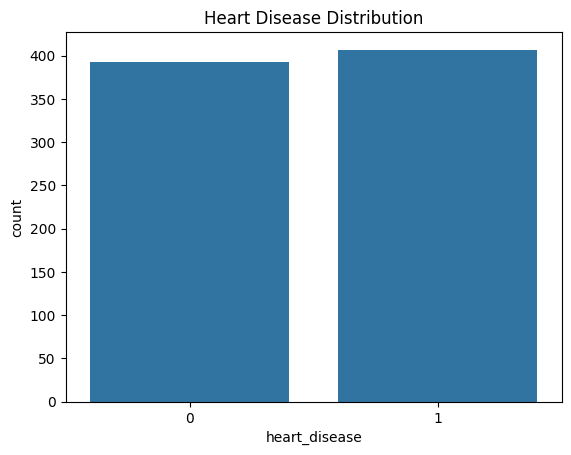

In [24]:
sns.countplot(x='heart_disease', data=df)
plt.title("Heart Disease Distribution")
plt.show()

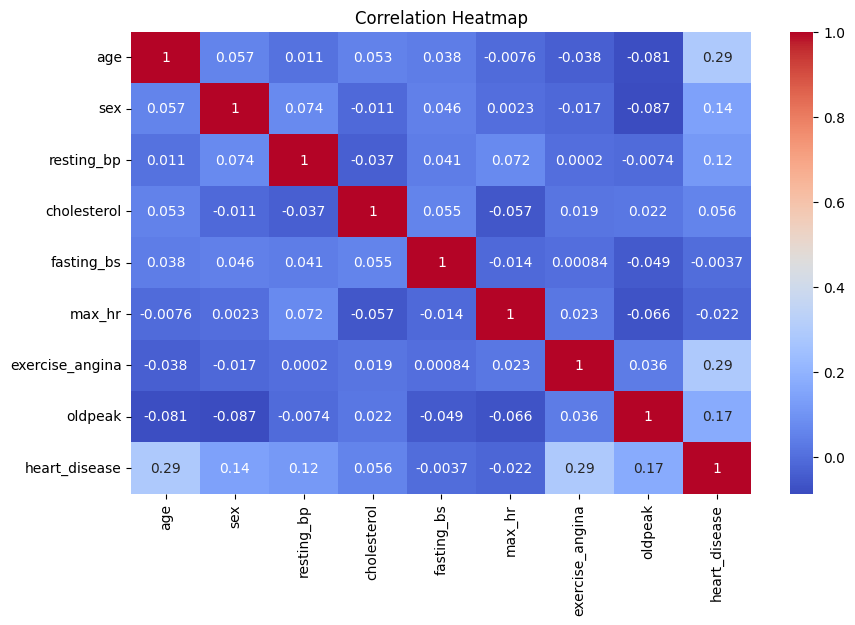

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

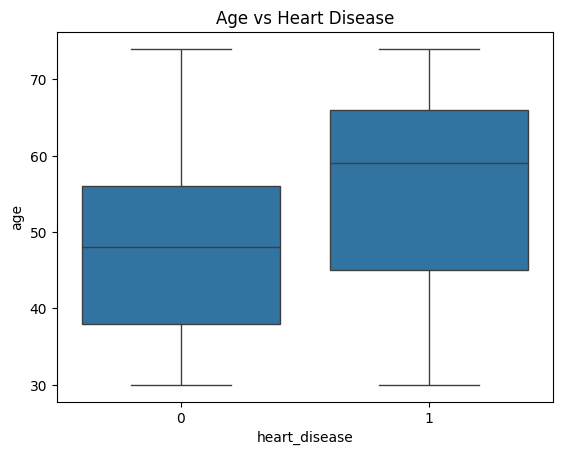

In [26]:
sns.boxplot(x='heart_disease', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.show()

In [27]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd

X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

# Separate columns
num_cols = X.select_dtypes(include=['number']).columns
cat_cols = X.select_dtypes(exclude=['number']).columns

# Impute numeric
num_imputer = SimpleImputer(strategy="mean")
X[num_cols] = num_imputer.fit_transform(X[num_cols])

# Impute categorical
cat_imputer = SimpleImputer(strategy="most_frequent")
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

# Convert categorical to numeric
X = pd.get_dummies(X, drop_first=True)

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
import pandas as pd
import numpy as np

# Split features and target
X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

# ✅ Convert target to numeric
y = pd.to_numeric(y, errors='coerce')
y = y.fillna(0).astype(int)

# ✅ Handle missing values
from sklearn.impute import SimpleImputer

num_cols = X.select_dtypes(include=['number']).columns
cat_cols = X.select_dtypes(exclude=['number']).columns

num_imputer = SimpleImputer(strategy='mean')
X[num_cols] = num_imputer.fit_transform(X[num_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

# ✅ Convert categorical to numeric
X = pd.get_dummies(X, drop_first=True)

# ✅ Ensure all values numeric
X = X.astype(float)

# ✅ Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ✅ Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔍 Debug check (VERY IMPORTANT)
print("NaN in X:", np.isnan(X).sum())
print("Unique y:", set(y))

NaN in X: 0
Unique y: {0, 1}


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [31]:
from sklearn.metrics import confusion_matrix, classification_report

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    print("\n====", name, "====")
    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
    print("Classification Report:\n", classification_report(y_test, preds))


==== Logistic Regression ====
Confusion Matrix:
 [[55 20]
 [19 66]]
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.73      0.74        75
           1       0.77      0.78      0.77        85

    accuracy                           0.76       160
   macro avg       0.76      0.75      0.76       160
weighted avg       0.76      0.76      0.76       160


==== Random Forest ====
Confusion Matrix:
 [[57 18]
 [15 70]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.76      0.78        75
           1       0.80      0.82      0.81        85

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


==== Gradient Boosting ====
Confusion Matrix:
 [[56 19]
 [13 72]]
Classification Report:
               precision    recall  f1-score   support

           0       0

- Missing values were handled using mean imputation.
- StandardScaler was applied to normalize feature values.
- Scaling improves performance of machine learning models.

- Random Forest performed best based on F1-score and accuracy.
- Logistic Regression was simple but slightly less accurate.
- Gradient Boosting also performed well but took more time.